In [1]:
# remember to put your personal access token in!
!git clone https://<pat>/LindyZhang/Emergent-Cooperation-In-DDZ.git

Cloning into 'Emergent-Cooperation-In-DDZ'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 82 (delta 10), reused 41 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 2.09 MiB | 844.00 KiB/s, done.
Resolving deltas: 100% (10/10), done.


In [2]:
%cd Emergent-Cooperation-In-DDZ/DouZero

/content/Emergent-Cooperation-In-DDZ/DouZero


In [3]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.0/269.0 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rlcard: filename=rlcard-1.2.0-py3-none-any.whl size=325795 sha256=cfd91c312f562f1c4e56093bf8f420988d6f851ea17c227d35a068a9f60a8e53
  Stored in directory: /root/.cache/pip/wheels/81/03/d4/d3d0f7d9f842d03627b91c6587472a1ba6a00b867a211531ba
Successfully built rlcard


In [4]:
!pip install torch torchvision

Partner randomized training: `douzero/dmc/utils.py`  
Asymmetric peasant learning: `douzero/dmc/dmc.py`  
Custom metrics/logging: `douzero/env/env.py`  
Cross play evaluation: `evaluate.py`  

  
The peasants are `landlord_up` and `landlord_down`. Environment reset assigns them their own hands before `card_play_init`

In [5]:
import torch
print(torch.cuda.is_available())

True


In [8]:
!python train_partner_randomized.py \
    --partner_random --pool_dir partner_pool \
    --partner_random_prob 0.3 \
    --savedir douzero_checkpoints --xpid partner_random_30

Streaming output truncated to the last 5000 lines.
{'loss_landlord': 2.0105295181274414,
 'loss_landlord_down': 2.1359877586364746,
 'loss_landlord_up': 1.6560848951339722,
 'mean_episode_return_landlord': 0.29045355319976807,
 'mean_episode_return_landlord_down': -0.2919810116291046,
 'mean_episode_return_landlord_up': -0.29276731610298157}
[INFO:12230 dmc_partner_random:495 2026-04-14 04:16:13,590] After 8169600 (L:2803200 U:2675200 D:2691200) frames: @ 0.0 fps (avg@ 559.8 fps) (L:0.0 U:0.0 D:0.0) Stats:
{'loss_landlord': 2.0105295181274414,
 'loss_landlord_down': 2.1359877586364746,
 'loss_landlord_up': 1.6560848951339722,
 'mean_episode_return_landlord': 0.29045355319976807,
 'mean_episode_return_landlord_down': -0.2919810116291046,
 'mean_episode_return_landlord_up': -0.29276731610298157}
[INFO:12230 dmc_partner_random:495 2026-04-14 04:16:18,596] After 8172800 (L:2806400 U:2675200 D:2691200) frames: @ 639.2 fps (avg@ 586.4 fps) (L:639.2 U:0.0 D:0.0) Stats:
{'loss_landlord': 1.776

In [11]:
!python train_partner_randomized.py \
    --partner_random --pool_dir partner_pool \
    --partner_random_prob 0.5 --partner_position both \
    --savedir douzero_checkpoints --xpid partner_random_both

Streaming output truncated to the last 5000 lines.
 'mean_episode_return_landlord_up': -0.22702939808368683}
[INFO:87040 dmc_partner_random:495 2026-04-14 08:37:29,681] After 5580800 (L:1916800 U:1820800 D:1843200) frames: @ 0.0 fps (avg@ 452.0 fps) (L:0.0 U:0.0 D:0.0) Stats:
{'loss_landlord': 1.820021152496338,
 'loss_landlord_down': 2.6937756538391113,
 'loss_landlord_up': 2.3094427585601807,
 'mean_episode_return_landlord': 0.22593432664871216,
 'mean_episode_return_landlord_down': -0.22681501507759094,
 'mean_episode_return_landlord_up': -0.22702939808368683}
[INFO:87040 dmc_partner_random:495 2026-04-14 08:37:34,683] After 5584000 (L:1916800 U:1820800 D:1846400) frames: @ 639.8 fps (avg@ 478.7 fps) (L:0.0 U:0.0 D:639.8) Stats:
{'loss_landlord': 1.820021152496338,
 'loss_landlord_down': 2.6609489917755127,
 'loss_landlord_up': 2.3094427585601807,
 'mean_episode_return_landlord': 0.22593432664871216,
 'mean_episode_return_landlord_down': -0.22848671674728394,
 'mean_episode_return_l

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_returns(csv_path, title, save_name=None):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(10, 6))
    plt.plot(df["frames"], df["mean_episode_return_landlord"], label="Landlord")
    plt.plot(df["frames"], df["mean_episode_return_landlord_up"], label="Peasant Up")
    plt.plot(df["frames"], df["mean_episode_return_landlord_down"], label="Peasant Down")

    plt.xlabel("Training Frames")
    plt.ylabel("Mean Episode Return")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

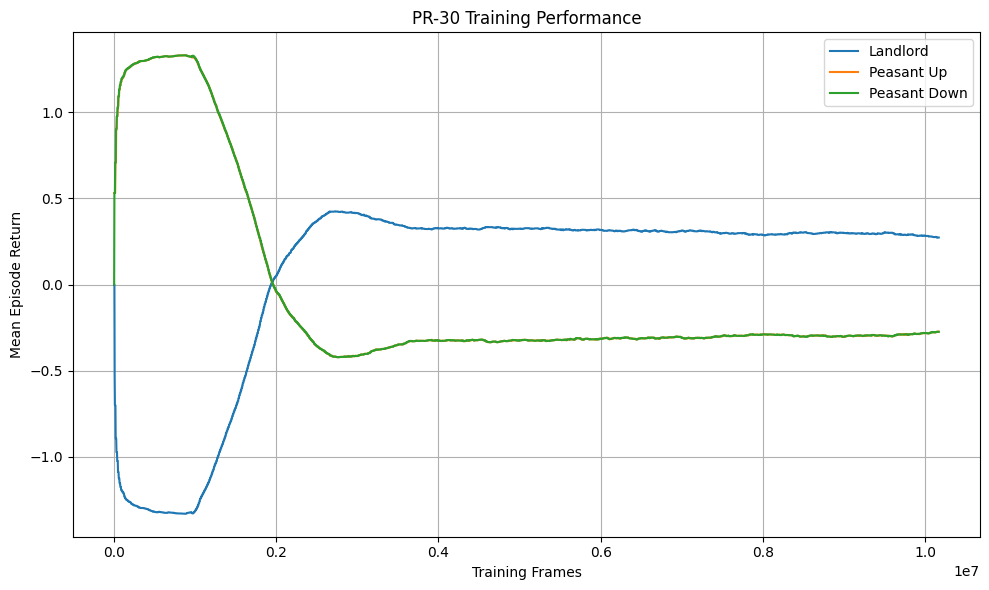

In [10]:
plot_training_returns(
    "/content/Emergent-Cooperation-In-DDZ/DouZero/douzero_checkpoints/partner_random_30/logs.csv",
    "PR-30 Training Performance",
    "pr30_training_returns.png"
)

/bin/bash: line 1: import: command not found


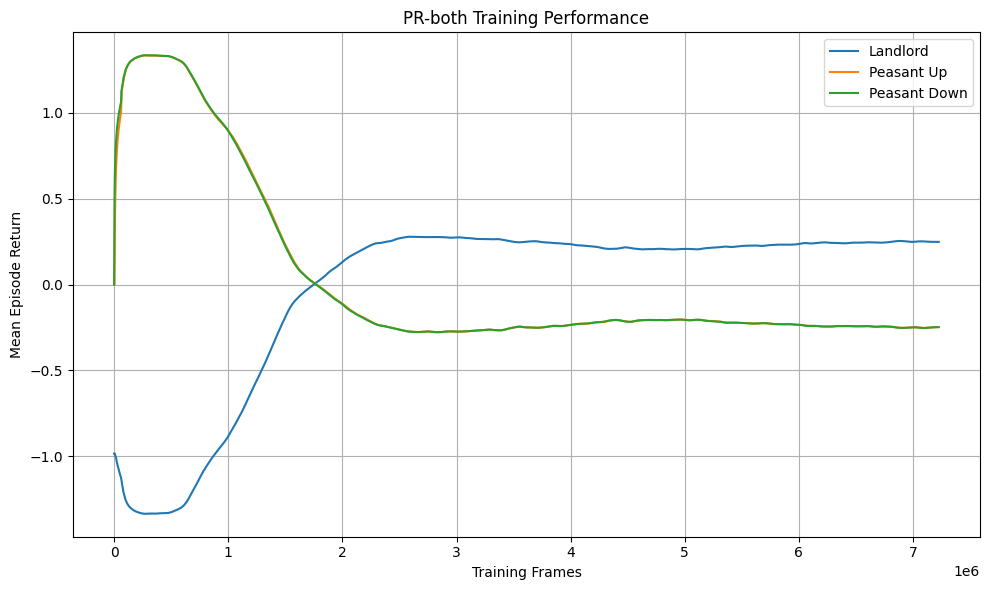

In [13]:
!import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Emergent-Cooperation-In-DDZ/DouZero/douzero_checkpoints/partner_random_both/logs.csv")

smooth = 20
plot_df = df.copy()
for col in ["mean_episode_return_landlord", "mean_episode_return_landlord_up", "mean_episode_return_landlord_down"]:
    plot_df[col] = plot_df[col].rolling(smooth, min_periods=1).mean()

plt.figure(figsize=(10,6))
plt.plot(plot_df["frames"], plot_df["mean_episode_return_landlord"], label="Landlord")
plt.plot(plot_df["frames"], plot_df["mean_episode_return_landlord_up"], label="Peasant Up")
plt.plot(plot_df["frames"], plot_df["mean_episode_return_landlord_down"], label="Peasant Down")

plt.xlabel("Training Frames")
plt.ylabel("Mean Episode Return")
plt.title("PR-both Training Performance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
!python train.py

Streaming output truncated to the last 5000 lines.
 'loss_landlord_up': 0.5571136474609375,
 'mean_episode_return_landlord': -1.4163525104522705,
 'mean_episode_return_landlord_down': 1.4171375036239624,
 'mean_episode_return_landlord_up': 1.4160367250442505}
[INFO:771 dmc:233 2026-03-11 02:39:10,320] After 329600 (L:112000 U:108800 D:108800) frames: @ 1279.6 fps (avg@ 693.1 fps) (L:639.8 U:639.8 D:0.0) Stats:
{'loss_landlord': 0.3862971365451813,
 'loss_landlord_down': 0.7290538549423218,
 'loss_landlord_up': 0.46872276067733765,
 'mean_episode_return_landlord': -1.418152093887329,
 'mean_episode_return_landlord_down': 1.4171375036239624,
 'mean_episode_return_landlord_up': 1.418141484260559}
[INFO:771 dmc:233 2026-03-11 02:39:15,321] After 332800 (L:112000 U:108800 D:112000) frames: @ 640.0 fps (avg@ 693.1 fps) (L:0.0 U:0.0 D:640.0) Stats:
{'loss_landlord': 0.3862971365451813,
 'loss_landlord_down': 0.3608654737472534,
 'loss_landlord_up': 0.46872276067733765,
 'mean_episode_return_l

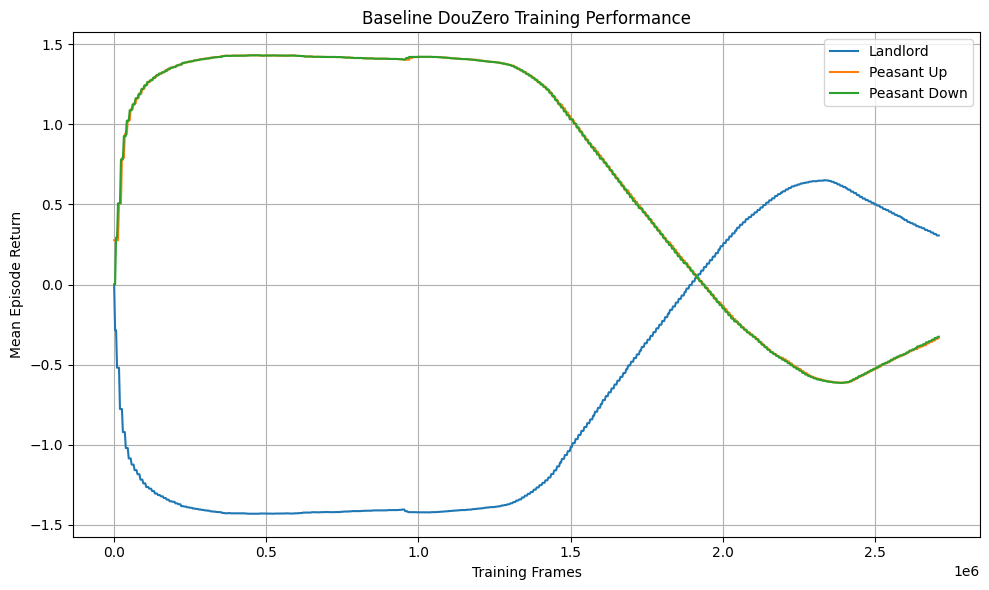

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Emergent-Cooperation-In-DDZ/DouZero/douzero_checkpoints/douzero/logs.csv")

plt.figure(figsize=(10,6))

plt.plot(df["frames"], df["mean_episode_return_landlord"], label="Landlord")
plt.plot(df["frames"], df["mean_episode_return_landlord_up"], label="Peasant Up")
plt.plot(df["frames"], df["mean_episode_return_landlord_down"], label="Peasant Down")

plt.xlabel("Training Frames")
plt.ylabel("Mean Episode Return")
plt.title("Baseline DouZero Training Performance")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("baseline_training_returns.png", dpi=300)

plt.show()

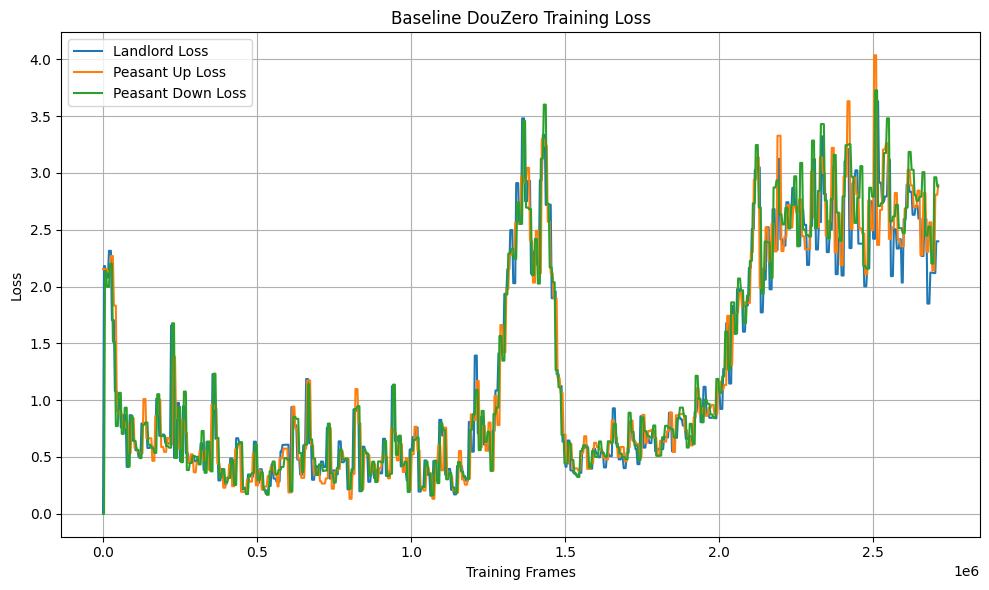

In [ ]:
df = pd.read_csv("/content/Emergent-Cooperation-In-DDZ/DouZero/douzero_checkpoints/douzero/logs.csv")

plt.figure(figsize=(10,6))

plt.plot(df["frames"], df["loss_landlord"], label="Landlord Loss")
plt.plot(df["frames"], df["loss_landlord_up"], label="Peasant Up Loss")
plt.plot(df["frames"], df["loss_landlord_down"], label="Peasant Down Loss")

plt.xlabel("Training Frames")
plt.ylabel("Loss")
plt.title("Baseline DouZero Training Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("baseline_training_loss.png", dpi=300)

plt.show()

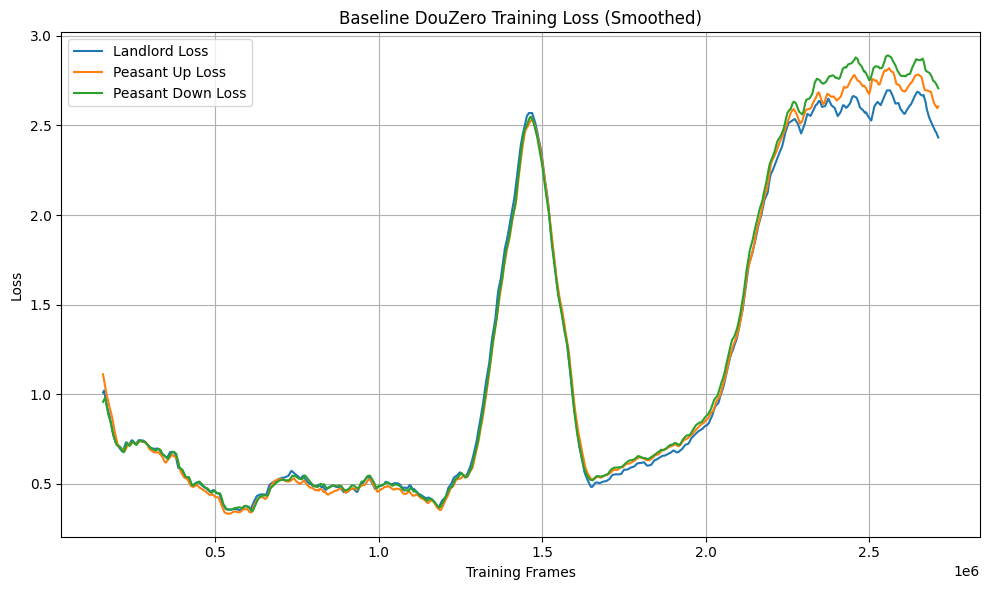

In [ ]:
window = 50

plt.figure(figsize=(10,6))

plt.plot(df["frames"], df["loss_landlord"].rolling(window).mean(), label="Landlord Loss")
plt.plot(df["frames"], df["loss_landlord_up"].rolling(window).mean(), label="Peasant Up Loss")
plt.plot(df["frames"], df["loss_landlord_down"].rolling(window).mean(), label="Peasant Down Loss")

plt.xlabel("Training Frames")
plt.ylabel("Loss")
plt.title("Baseline DouZero Training Loss (Smoothed)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("baseline_training_loss.png", dpi=300)

plt.show()

In [ ]:
!python train.py --savedir douzero_checkpoints --xpid asym_freeze_down

Streaming output truncated to the last 5000 lines.
 'mean_episode_return_landlord_up': 1.235246181488037}
[INFO:21707 dmc:238 2026-03-11 03:58:12,886] After 211200 (L:70400 U:70400 D:70400) frames: @ 640.0 fps (avg@ 666.5 fps) (L:0.0 U:640.0 D:0.0) Stats:
{'loss_landlord': 0.3987371623516083,
 'loss_landlord_down': 2.000873327255249,
 'loss_landlord_up': 0.578450083732605,
 'mean_episode_return_landlord': -1.2354514598846436,
 'mean_episode_return_landlord_down': 1.2353826761245728,
 'mean_episode_return_landlord_up': 1.238976240158081}
[INFO:21707 dmc:238 2026-03-11 03:58:17,889] After 211200 (L:70400 U:70400 D:70400) frames: @ 0.0 fps (avg@ 639.9 fps) (L:0.0 U:0.0 D:0.0) Stats:
{'loss_landlord': 0.3987371623516083,
 'loss_landlord_down': 2.000873327255249,
 'loss_landlord_up': 0.578450083732605,
 'mean_episode_return_landlord': -1.2354514598846436,
 'mean_episode_return_landlord_down': 1.2353826761245728,
 'mean_episode_return_landlord_up': 1.238976240158081}
[INFO:21707 dmc:238 2026

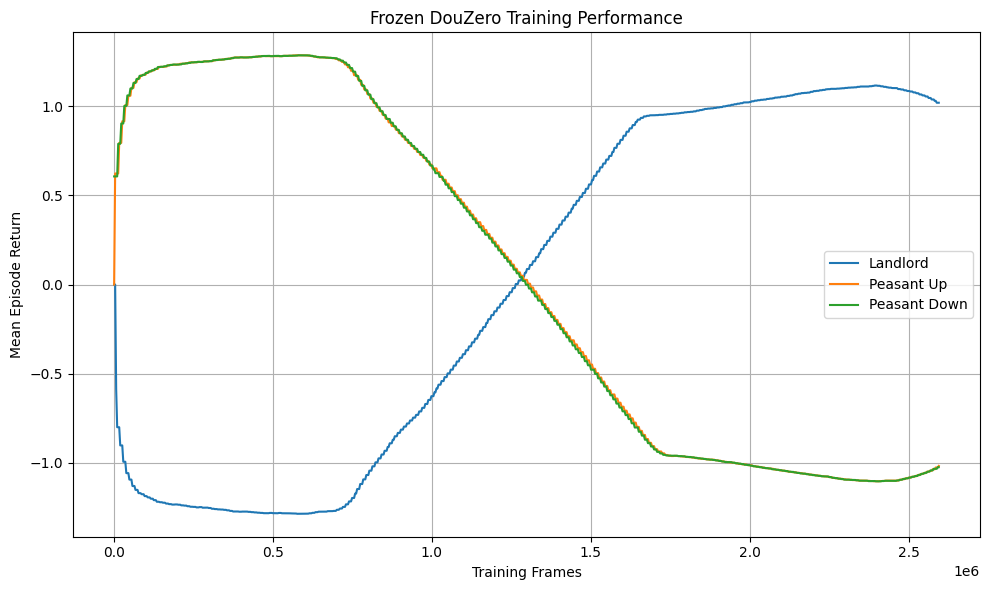

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Emergent-Cooperation-In-DDZ/DouZero/douzero_checkpoints/asym_freeze_down/logs.csv")

plt.figure(figsize=(10,6))

plt.plot(df["frames"], df["mean_episode_return_landlord"], label="Landlord")
plt.plot(df["frames"], df["mean_episode_return_landlord_up"], label="Peasant Up")
plt.plot(df["frames"], df["mean_episode_return_landlord_down"], label="Peasant Down")

plt.xlabel("Training Frames")
plt.ylabel("Mean Episode Return")
plt.title("Frozen DouZero Training Performance")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("freeze_training_returns.png", dpi=300)

plt.show()

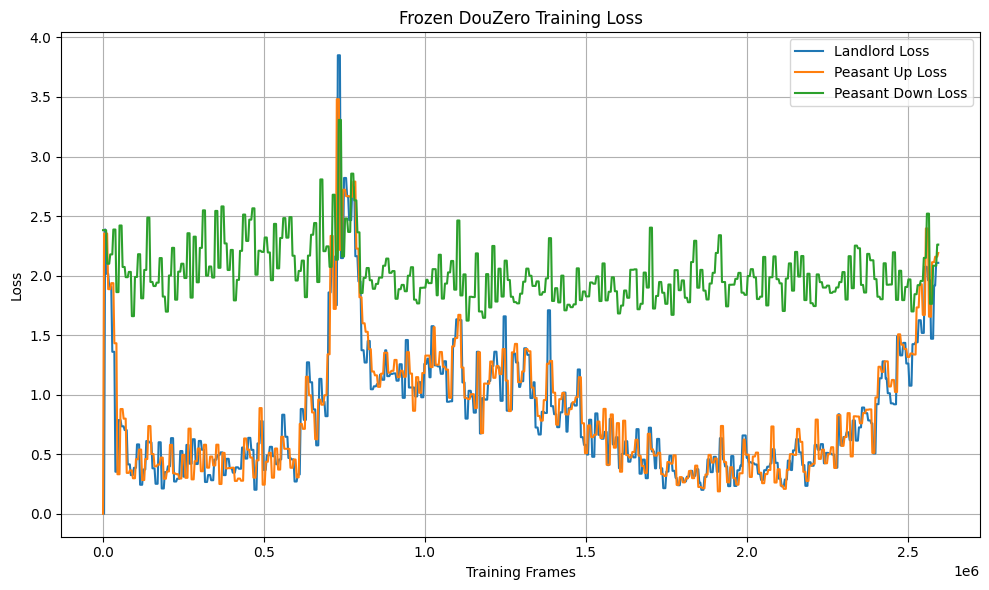

In [ ]:
df = pd.read_csv("/content/Emergent-Cooperation-In-DDZ/DouZero/douzero_checkpoints/asym_freeze_down/logs.csv")

plt.figure(figsize=(10,6))

plt.plot(df["frames"], df["loss_landlord"], label="Landlord Loss")
plt.plot(df["frames"], df["loss_landlord_up"], label="Peasant Up Loss")
plt.plot(df["frames"], df["loss_landlord_down"], label="Peasant Down Loss")

plt.xlabel("Training Frames")
plt.ylabel("Loss")
plt.title("Frozen DouZero Training Loss")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("frozen_training_loss.png", dpi=300)

plt.show()

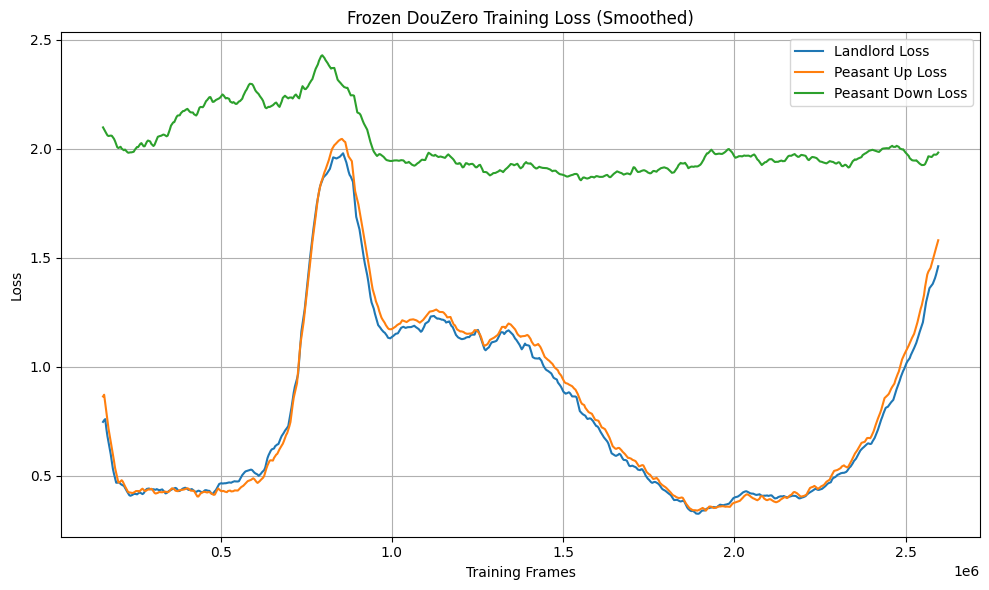

In [ ]:
window = 50

plt.figure(figsize=(10,6))

plt.plot(df["frames"], df["loss_landlord"].rolling(window).mean(), label="Landlord Loss")
plt.plot(df["frames"], df["loss_landlord_up"].rolling(window).mean(), label="Peasant Up Loss")
plt.plot(df["frames"], df["loss_landlord_down"].rolling(window).mean(), label="Peasant Down Loss")

plt.xlabel("Training Frames")
plt.ylabel("Loss")
plt.title("Frozen DouZero Training Loss (Smoothed)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("frozen_smoothed_training_loss.png", dpi=300)

plt.show()